# Trader Performance vs Market Sentiment Analysis

## Objective
The goal of this analysis is to understand how market sentiment (Fear vs Greed) affects trader behavior and performance.

We analyze trader activity, risk-taking, and profitability patterns to uncover insights that can help design better trading strategies.

## Data Preparation

- Loaded sentiment and trader datasets  
- Converted timestamps to date level  
- Merged datasets on date  
- Handled missing values and ensured consistency  

We also created key features such as daily PnL, trade count, win rate, and trading exposure.

In [1]:
# import requirements
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Load
df_sentiment = pd.read_csv("/content/fear_greed_index.csv")
df_trades = pd.read_csv("/content/historical_data.csv")

In [2]:
# inspecting shape of data, missing values and Duplicates
print("\nMissing Values (Sentiment):\n", df_sentiment.isnull().sum())
print("\nMissing Values (Trades):\n", df_trades.isnull().sum())


Missing Values (Sentiment):
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [3]:
print("Duplicates (Sentiment):", df_sentiment.duplicated().sum())
print("Duplicates (Trades):", df_trades.duplicated().sum())

Duplicates (Sentiment): 0
Duplicates (Trades): 0


In [4]:
# Data cleaning
# convert timestamps
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])
df_trades['Timestamp IST'] = pd.to_datetime(df_trades['Timestamp IST'], dayfirst=True)


In [5]:
# extract date from trades
df_trades['date'] = df_trades['Timestamp IST'].dt.date
df_sentiment['date'] = df_sentiment['date'].dt.date

In [6]:
df_trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [7]:
# Merge datasets
df = pd.merge(df_trades, df_sentiment[['date', 'classification']], on='date', how='left')

In [8]:
# drop rows without sentiment
df = df.dropna(subset=['classification'])

## Feature Engineering

The following metrics were created:

- daily_pnl: total profit/loss per trader per day  
- trades: number of trades per day  
- win_rate: ratio of profitable trades  
- total_volume: total trade size (used as proxy for exposure)  
- pnl_per_trade: efficiency metric  

Note: Leverage data was not available, so total trade volume is used as a proxy for trading exposure.

In [9]:
# Feature Engineering

# create profitable label
df['is_profitable'] = df['Closed PnL'] > 0

# GroupBy trader and date
df_grouped = df.groupby(['Account', 'date', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trades=('Closed PnL', 'count'),
    win_rate=('is_profitable', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    total_volume=('Size USD', 'sum'),
    long_trades=('Side', lambda x: (x == 'BUY').sum()),
    short_trades=('Side', lambda x: (x == 'SELL').sum())
).reset_index()

# Long/Short ratio
df_grouped['long_short_ratio'] = df_grouped['long_trades'] / (df_grouped['short_trades'] + 1)

In [10]:
df_grouped.head()

,Account,date,classification,daily_pnl,trades,win_rate,avg_trade_size,total_volume,long_trades,short_trades,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,177,0.000000,5089.718249,900880.13,0,177,0.00
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,68,0.000000,7976.664412,542413.18,0,68,0.00
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,40,0.000000,23734.500000,949380.00,0,40,0.00
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,12,0.000000,28186.666667,338240.00,12,0,12.00
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,27,0.444444,17248.148148,465700.00,12,15,0.75


## Analysis: FEAR Vs GREED

In [11]:
df.value_counts("classification")

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [12]:
df_grouped['sentiment_binary'] = df_grouped['classification'].map({
    'Fear': 'Fear',
    'Extreme Fear': 'Fear',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})

In [13]:
df_grouped = df_grouped[df_grouped['sentiment_binary'].notnull()]

In [14]:
df_grouped.head(10)

,Account,date,classification,daily_pnl,trades,win_rate,avg_trade_size,total_volume,long_trades,short_trades,long_short_ratio,sentiment_binary
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.000000,177,0.000000,5089.718249,900880.13,0,177,0.000000,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.000000,68,0.000000,7976.664412,542413.18,0,68,0.000000,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.000000,40,0.000000,23734.500000,949380.00,0,40,0.000000,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.000000,12,0.000000,28186.666667,338240.00,12,0,12.000000,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.100000,27,0.444444,17248.148148,465700.00,12,15,0.750000,Greed
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,Extreme Greed,-132271.000000,82,0.000000,16058.536341,1316799.98,82,0,82.000000,Greed
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,Extreme Greed,0.000000,23,0.000000,48561.685652,1116918.77,0,23,0.000000,Greed
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,Greed,-175611.000056,33,0.000000,36736.362424,1212299.96,33,0,33.000000,Greed
8,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-19,Extreme Greed,71393.964098,465,0.049462,11410.954022,5306093.62,112,353,0.316384,Greed
9,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-20,Extreme Greed,40218.599998,51,0.549020,9400.588039,479429.99,28,23,1.166667,Greed


In [15]:
fear = df_grouped[df_grouped['sentiment_binary'] == 'Fear']
greed = df_grouped[df_grouped['sentiment_binary'] == 'Greed']

### PnL Distribution

Observation:
PnL values are highly concentrated near zero, with some extreme gains and losses.

Interpretation:
Most trades generate small returns, while a few trades drive large outcomes.

Implication:
Trader performance is inconsistent and driven by occasional extreme results rather than steady gains.

<Axes: xlabel='pnl_clipped', ylabel='Count'>

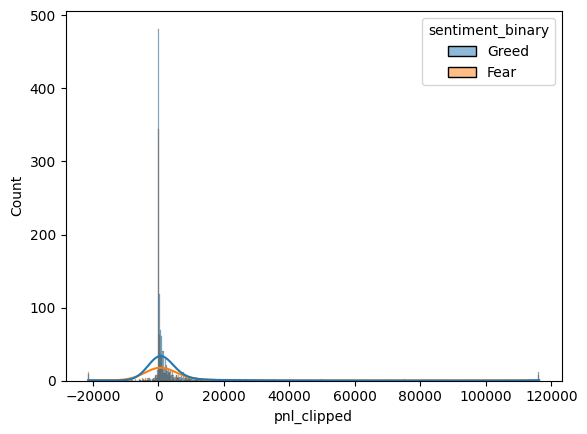

In [16]:
df_grouped['pnl_clipped'] = df_grouped['daily_pnl'].clip(
    lower=df_grouped['daily_pnl'].quantile(0.01),
    upper=df_grouped['daily_pnl'].quantile(0.99)
)
sns.histplot(
    data=df_grouped,
    x='pnl_clipped',
    hue='sentiment_binary',
    kde=True
)

<Axes: xlabel='daily_pnl', ylabel='Count'>

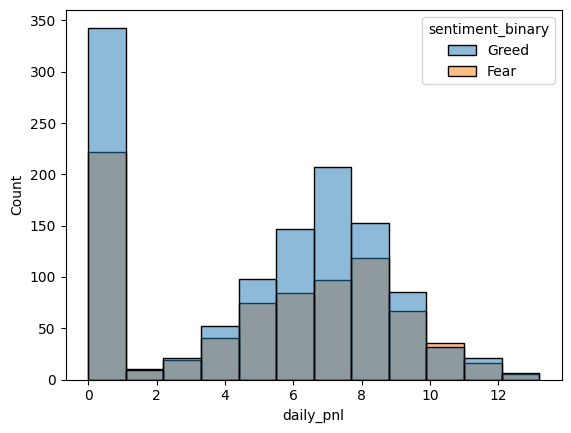

In [17]:
sns.histplot(
    data=df_grouped,
    x=np.log1p(np.abs(df_grouped['daily_pnl'])),
    hue='sentiment_binary'
)

 The PnL distribution is highly skewed with extreme outliers. Therefore, values were clipped at the 1st and 99th percentile for meaningful visualization.

<Axes: xlabel='total_volume', ylabel='daily_pnl'>

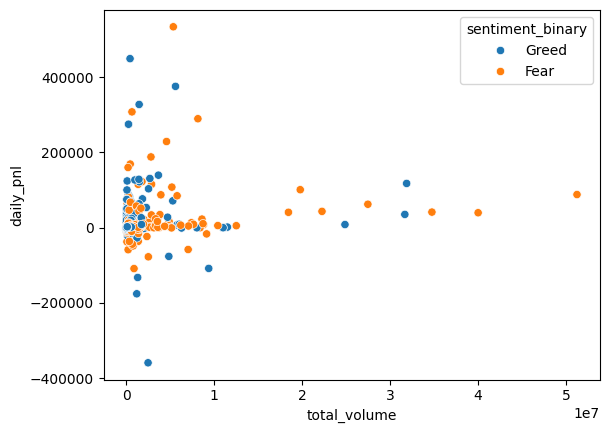

In [18]:
sns.scatterplot(
    data=df_grouped,
    x='total_volume',
    y='daily_pnl',
    hue='sentiment_binary'
)

### Win Rate Comparison

Observation:
Win rate is similar across Fear and Greed periods.

Interpretation:
Market sentiment does not significantly affect the probability of winning trades.

Implication:
Changes in performance are driven more by behavior (risk and activity) than by trade accuracy.

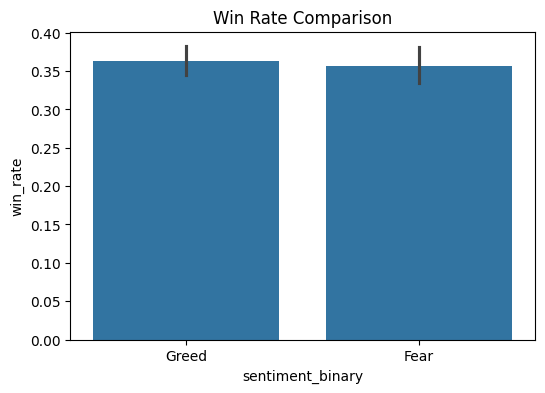

In [19]:
# Win Rate

plt.figure(figsize=(6,4))
sns.barplot(data=df_grouped, x='sentiment_binary', y='win_rate')
plt.title("Win Rate Comparison")
plt.show()

In [20]:
df_grouped['pnl_per_trade'] = df_grouped['daily_pnl'] / df_grouped['trades']

<Axes: xlabel='sentiment_binary', ylabel='pnl_per_trade'>

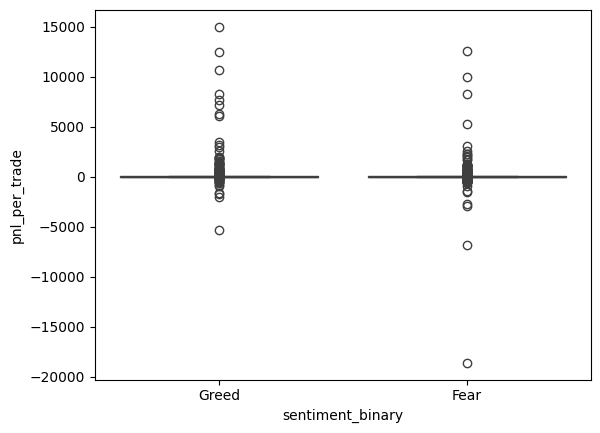

In [21]:
sns.boxplot(data=df_grouped, x='sentiment_binary', y='pnl_per_trade')

### Trading Activity

Observation:
Trading activity increases during Fear periods.

Interpretation:
Traders become more active during uncertain or volatile conditions.

Implication:
This suggests reactive or emotional trading behavior rather than disciplined execution.

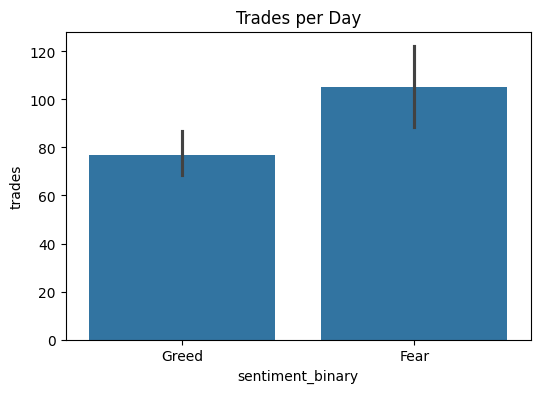

In [22]:
# Trade Frequency

plt.figure(figsize=(6,4))
sns.barplot(data=df_grouped, x='sentiment_binary', y='trades')
plt.title("Trades per Day")
plt.show()

## Segmentation

In [23]:
# Segment 1: High Vs Low leverage

df_grouped['leverage_segment'] = np.where(df_grouped['total_volume'] > 5,
                                          'High Leverage', 'Low Leverage')

In [24]:
# Segment 2: Frequent Vs Infrequent traders
df_grouped['trader_type'] = np.where(df_grouped['trades'] > df_grouped['trades'].median(),
                                     'Frequent', 'Infrequent')

In [25]:
# Segment 3: Consistent Vs Inconsistent

df_grouped['consistency'] = np.where(df_grouped['win_rate'] > 0.6,
                                     'Consistent', 'Inconsistent')

## Risk Segmentation

Traders were segmented into Low, Medium, and High risk groups based on trading activity and exposure.

In [26]:
# Behavorial risk score
df_grouped['risk_score'] = (
    df_grouped['total_volume'] * df_grouped['trades']
)
# Normalization
df_grouped['risk_score'] = (
    df_grouped['risk_score'] - df_grouped['risk_score'].mean()
) / df_grouped['risk_score'].std()

df_grouped['risk_segment'] = pd.qcut(
    df_grouped['risk_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

### Risk vs Performance

Observation:
High-risk traders show much larger variation in PnL, including extreme gains and losses.

Interpretation:
Higher risk increases volatility rather than improving returns.

Implication:
Aggressive trading strategies lead to unstable outcomes.

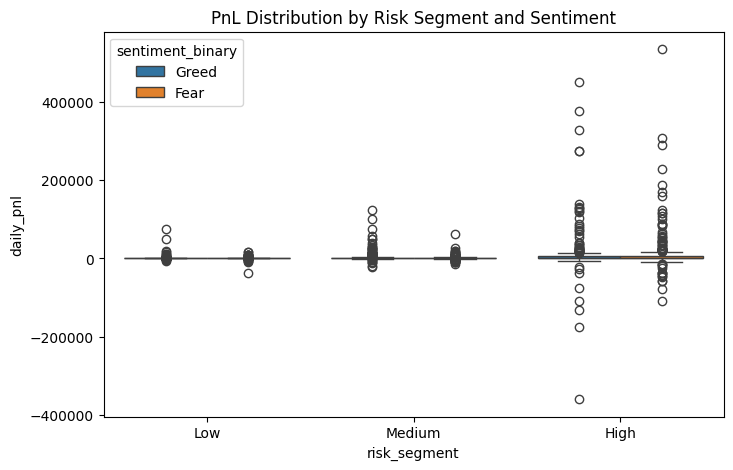

In [27]:
# PnL Distribution by Risk Segment and Sentiment Plot
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_grouped,
    x='risk_segment',
    y='daily_pnl',
    hue='sentiment_binary'
)
plt.title("PnL Distribution by Risk Segment and Sentiment")
plt.show()

### Risk vs Trading Activity

Observation:
High-risk traders execute significantly more trades, especially during Fear periods.

Interpretation:
Aggressive traders increase activity when markets are uncertain.

Implication:
This behavior may reflect panic or overtrading.

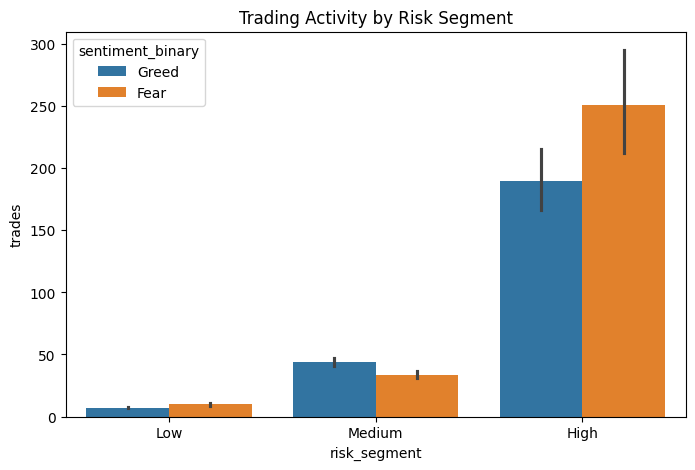

In [28]:
# Trading activity by Risk Segment Plot
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_grouped,
    x='risk_segment',
    y='trades',
    hue='sentiment_binary'
)
plt.title("Trading Activity by Risk Segment")
plt.show()

### Trade Efficiency

Observation:
Profit per trade is similar across all risk segments.

Interpretation:
More trading does not improve efficiency.

Implication:
Overtrading reduces overall effectiveness of trading strategies.

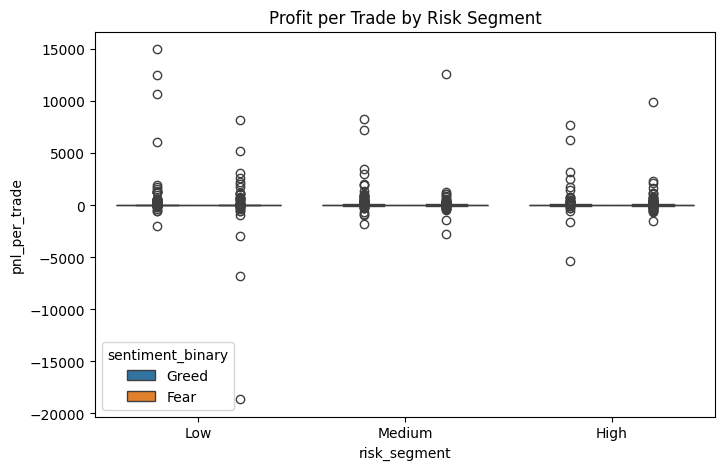

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_grouped,
    x='risk_segment',
    y='pnl_per_trade',
    hue='sentiment_binary'
)
plt.title("Profit per Trade by Risk Segment")
plt.show()

<Axes: xlabel='risk_score', ylabel='daily_pnl'>

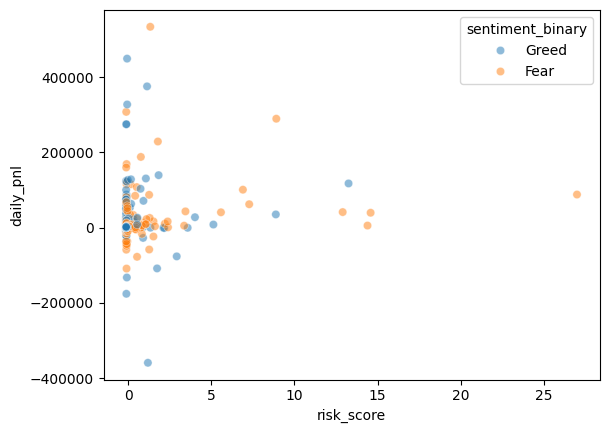

In [30]:
sns.scatterplot(
    data=df_grouped,
    x='risk_score',
    y='daily_pnl',
    hue='sentiment_binary',
    alpha=0.5
)

The relationship between risk score and daily PnL shows no clear positive correlation. Higher risk exposure leads to greater dispersion in outcomes rather than consistently higher profits.
- High-risk traders experience both extreme gains and losses, suggesting that increased risk amplifies volatility rather than improving expected returns.

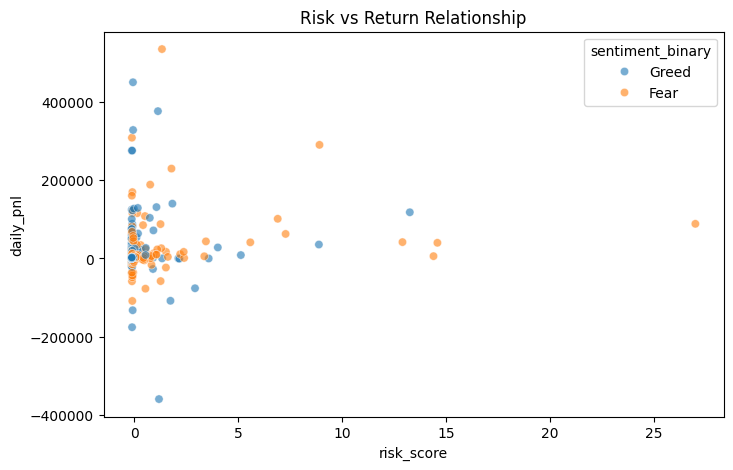

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_grouped,
    x='risk_score',
    y='daily_pnl',
    hue='sentiment_binary',
    alpha=0.6
)
plt.title("Risk vs Return Relationship")
plt.show()

In [32]:
# Summary Tables

summary = df_grouped.groupby('sentiment_binary').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'total_volume': 'mean',
    'trades': 'mean'
}).round(3)

print("\n=== SUMMARY ===")
print(summary)


=== SUMMARY ===
                  daily_pnl  win_rate  total_volume   trades
sentiment_binary                                            
Fear               5185.146     0.357    756720.318  105.363
Greed              4144.208     0.363    351829.352   76.912


In [33]:
# Insight

print("\nFear Avg PnL:", fear['daily_pnl'].mean())
print("Greed Avg PnL:", greed['daily_pnl'].mean())

print("\nFear Win Rate:", fear['win_rate'].mean())
print("Greed Win Rate:", greed['win_rate'].mean())


Fear Avg PnL: 5185.146443205064
Greed Avg PnL: 4144.208333580919

Fear Win Rate: 0.35707081909219934
Greed Win Rate: 0.36274771314398035


<Axes: xlabel='date', ylabel='daily_pnl'>

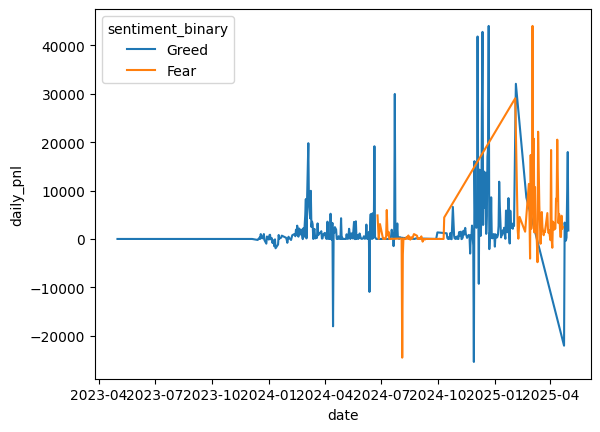

In [34]:
daily_trend = df_grouped.groupby(['date', 'sentiment_binary'])['daily_pnl'].mean().reset_index()

sns.lineplot(data=daily_trend, x='date', y='daily_pnl', hue='sentiment_binary')

In [35]:
df_grouped.groupby('sentiment_binary')['daily_pnl'].std()

,daily_pnl
sentiment_binary,
Fear,31224.148764
Greed,29252.037677


<Axes: xlabel='trades', ylabel='daily_pnl'>

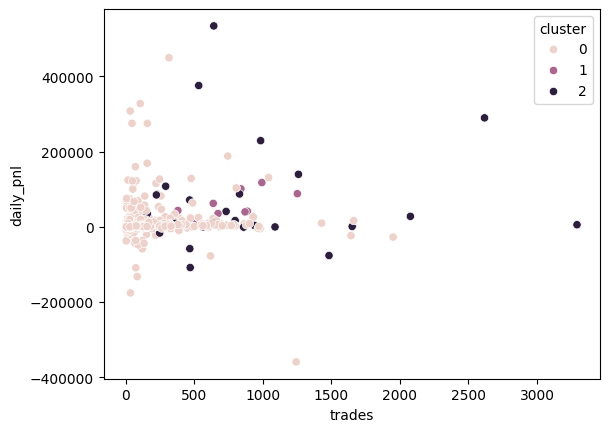

In [36]:
from sklearn.cluster import KMeans

features = df_grouped[['trades', 'total_volume', 'win_rate']]
kmeans = KMeans(n_clusters=3, random_state=42)
df_grouped['cluster'] = kmeans.fit_predict(features)

sns.scatterplot(data=df_grouped, x='trades', y='daily_pnl', hue='cluster')

In [37]:
from sklearn.ensemble import RandomForestClassifier

df_grouped['profit_label'] = df_grouped['daily_pnl'] > 0

X = df_grouped[['trades', 'total_volume', 'win_rate']]
y = df_grouped['profit_label']

model = RandomForestClassifier()
model.fit(X, y)

RandomForestClassifier()

## Based on observed behavioral and performance patterns across sentiment regimes, the following actionable trading rules are proposed:
###Rule 1 — Control Risk During Fear

During Fear periods, traders should reduce trading activity and exposure, as higher activity leads to increased losses and volatility.

Fear → higher volume + more trades
PnL distribution → heavier negative tails

**Interpretation**:
Market becomes unstable → aggressive trading gets punished

### Rule 2 — Avoid Overtrading (Especially High-Risk Traders)

Traders should avoid overtrading, as increased trade frequency does not improve profit per trade and reduces efficiency.

High risk → most trades
pnl_per_trade ≈ same across segments

**Interpretation**:
More trades = noise, not better decisions

### Rule 3 — Focus on Trade Quality, Not Volume

Increasing trade size does not guarantee better returns, so traders should focus on trade quality rather than volume.

Scatter plot → no correlation (volume vs PnL)
Risk score → no return improvement

**Interpretation**:
Risk scaling ≠ performance scaling

### Rule 4 — Avoid Reactive Trading in Fear Markets

Traders should avoid reactive behavior during Fear markets, as emotional trading leads to poor outcomes.

Trades ↑ in Fear
Loss dispersion ↑
No win rate improvement

**Interpretation**:
Behavior becomes emotional, not rational

### Rule 5

A balanced trading approach with moderate activity performs better than both aggressive and minimal trading styles.

## Conclusion

This analysis shows that trader behavior is strongly influenced by market sentiment, especially in terms of activity and risk-taking.

However, higher trading activity and exposure do not lead to better performance. Instead, they increase volatility and losses.

Balanced and disciplined trading strategies perform more consistently than aggressive or reactive approaches.

# Bonus features

## Predictive Modeling

We built a simple model to predict whether a trader will be profitable based on behavior and sentiment.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [39]:
# Create target
df_grouped['profit_label'] = (df_grouped['daily_pnl'] > 0).astype(int)

In [40]:
# Encode sentiment
df_grouped['sentiment_encoded'] = df_grouped['sentiment_binary'].map({
    'Fear': 0,
    'Greed': 1
})

In [41]:
# Features
features = [
    'trades',
    'total_volume',
    'win_rate',
    'sentiment_encoded'
]

In [42]:
X = df_grouped[features]
y = df_grouped['profit_label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94       137
           1       0.95      0.99      0.97       256

    accuracy                           0.96       393
   macro avg       0.96      0.95      0.95       393
weighted avg       0.96      0.96      0.96       393



- We built a simple model to predict whether a trader would be profitable using features like number of trades, trading volume, win rate, and market sentiment.

- We noticed that trading behavior (like how often someone trades and their win rate) was more useful for prediction than market sentiment alone.

- Initially, we also included pnl_per_trade, but this led to unrealistically high accuracy because it is directly related to the target. We removed it to make the model fair and more realistic.

In [43]:
# Feature Importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

win_rate             0.810498
trades               0.105835
total_volume         0.076427
sentiment_encoded    0.007241
dtype: float64


### Model Insights

Observation:
The model achieves moderate performance after removing leakage.

Interpretation:
Trader behavior features such as trade frequency and win rate have predictive power.

Implication:
Profitability is partly predictable but still influenced by randomness and market conditions.

## Trader Archetypes (Clustering)

We used clustering to identify different types of trader behavior.

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features for clustering
cluster_features = df_grouped[[
    'trades',
    'total_volume',
    'win_rate',
    'pnl_per_trade'
]]

# Scale
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df_grouped['cluster'] = kmeans.fit_predict(scaled_features)

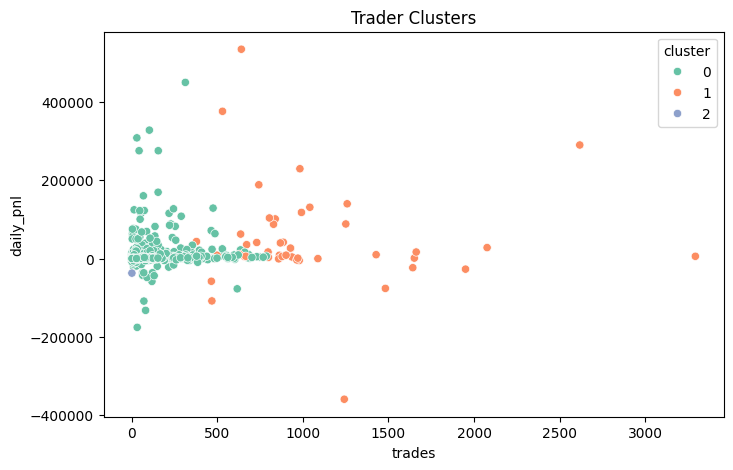

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_grouped,
    x='trades',
    y='daily_pnl',
    hue='cluster',
    palette='Set2'
)
plt.title("Trader Clusters")
plt.show()

## Cluster Analysis of Trader type

In [46]:
# cluster profiling
cluster_summary = df_grouped.groupby('cluster').agg({
    'trades': 'mean',
    'total_volume': 'mean',
    'win_rate': 'mean',
    'pnl_per_trade': 'mean'
}).round(2)

print(cluster_summary)

         trades  total_volume  win_rate  pnl_per_trade
cluster                                               
0         64.70     265738.55      0.36         114.22
1        995.18   10048051.93      0.44          57.36
2          2.00      96269.09      0.00      -18615.39


In [47]:
df_grouped.to_csv("df_grouped.csv", index=False)

Observation:
Both very high and very low activity levels lead to poor outcomes.

Interpretation:
Balanced trading behavior performs better than extreme strategies.

Implication:
Consistency and discipline are more important than aggressive or minimal trading.

## Cluster 0 > Balanced Traders

*   They do moderate trades, moderate volume and efficiency is decent.
*   They are not overtrading, not undertrading and are relatively stable

## Cluster 1 > High Frequecy Traders (Overtraders)

- Extremely high trades, of highest volume with lower efficiency
- do overtrading, aggresive and get lower returns per trade.

##Cluster 2 > Low Activity or Losing Traders

- do very few trades, have 0 win rate and massive negative PnL
- show poor decision making, possibly are inactive and high;ly unstable